## Goal
Analyze customer purchase behavior over time and identify products that are frequently bought together.
Key questions:

How do customers behave over time?

Are there seasonal or time-based purchasing patterns?

Which products are commonly bought together?

How can this support cross-selling and bundling strategies?

In [23]:
# Setup
import pandas as pd

# Load dataset (relative path)
df = pd.read_csv(
    "../data/online-retail-cleaned.csv",
    encoding="ISO-8859-1"
)

# Basic cleaning
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Final clean dataset
df_clean = df.copy()

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,yearmonth,date,dayofweek,hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2010-12-01,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2010-12-01,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8


# 1️⃣ Cohort Analysis

Cohort analysis groups customers based on the month of their first purchase and tracks their behavior over time.

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
# Cohort Analysis
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean['Cohort'] = df_clean.groupby('CustomerID')['InvoiceDate'] \
                             .transform('min') \
                             .dt.to_period('M')

# 2️⃣ Customer Retention Matrix

In [31]:
cohort_data = df_clean.groupby(['Cohort', 'InvoiceMonth']).agg({
    'CustomerID': 'nunique'
}).reset_index()

# Calculate cohort index
cohort_data['CohortIndex'] = (
    cohort_data['InvoiceMonth'] - cohort_data['Cohort']
).apply(lambda x: x.n)

In [33]:
# Pivot table for retention matrix
cohort_pivot = cohort_data.pivot_table(
    index='Cohort',
    columns='CohortIndex',
    values='CustomerID'
)

# Convert to percentage
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)

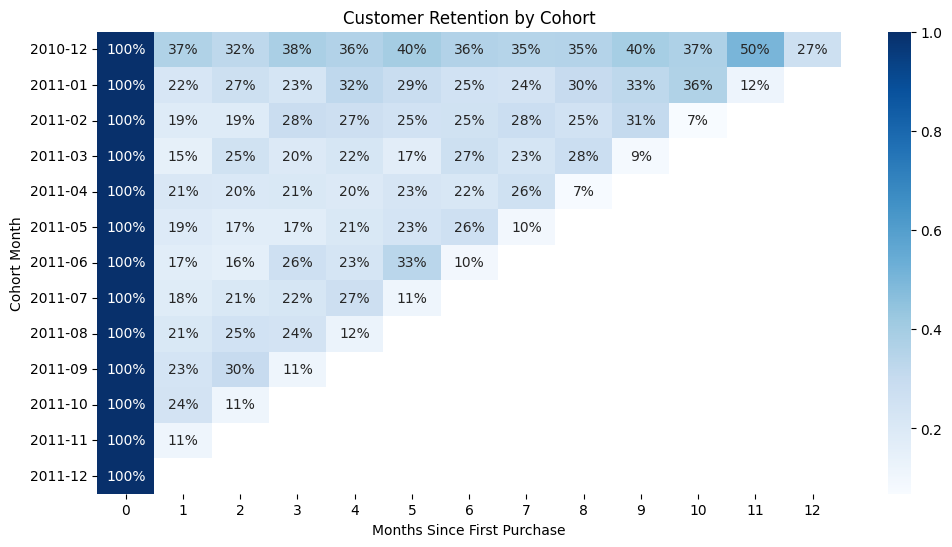

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure and axis explicitly
fig, ax = plt.subplots(figsize=(12, 6))

# Plot heatmap
sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues",
    ax=ax
)

# Styling
ax.set_title("Customer Retention by Cohort")
ax.set_ylabel("Cohort Month")
ax.set_xlabel("Months Since First Purchase")
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

# Save the image
fig.savefig(
    "../images/customer_retention_heatmap.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

# Display the plot
plt.show()

# 3️⃣ Seasonality Analysis

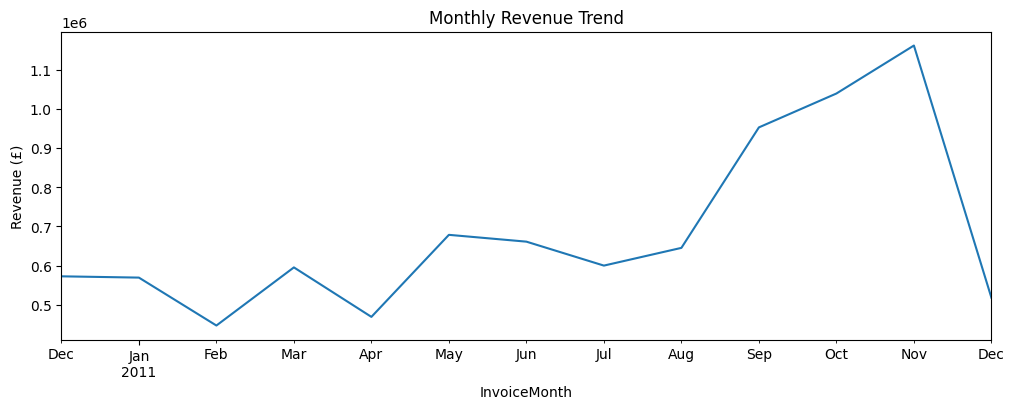

In [38]:
# Monthly revenue trend
monthly_revenue = df_clean.groupby('InvoiceMonth')['Revenue'].sum()

monthly_revenue.plot(kind='line', figsize=(12, 4), title='Monthly Revenue Trend')
plt.ylabel('Revenue (£)')
plt.show()

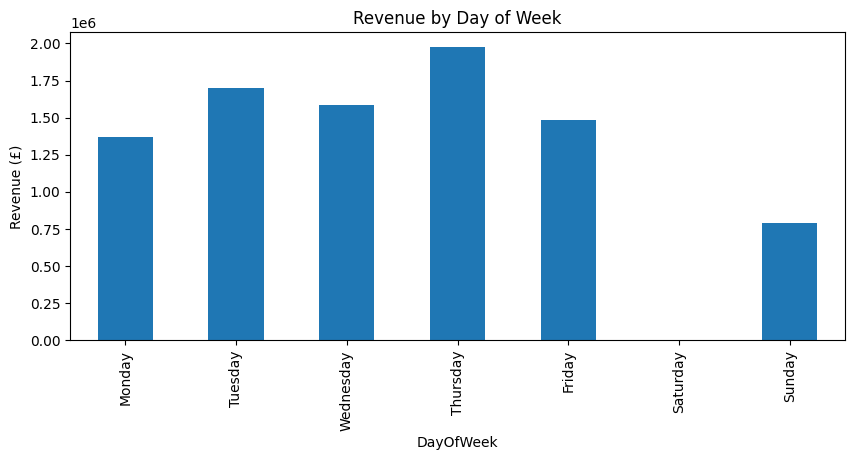

In [19]:
# Day of week pattern
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()

dow_revenue = df_clean.groupby('DayOfWeek')['Revenue'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

dow_revenue.plot(kind='bar', figsize=(10, 4), title='Revenue by Day of Week')
plt.ylabel('Revenue (£)')
plt.show()

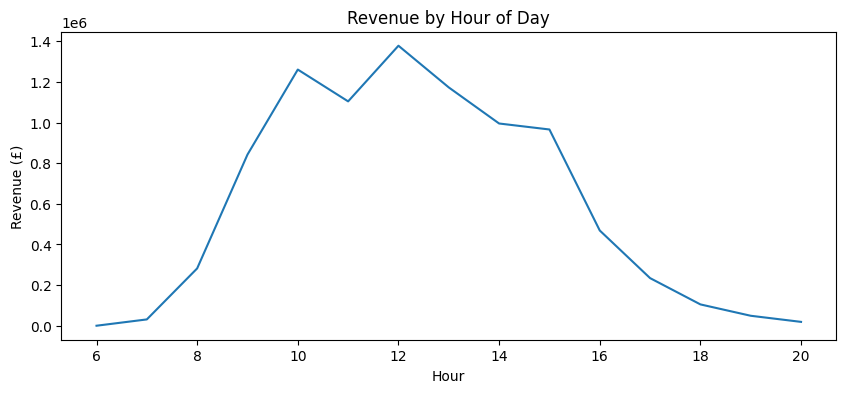

In [21]:
# Hourly purchase pattern
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

hourly_revenue = df_clean.groupby('Hour')['Revenue'].sum()

hourly_revenue.plot(kind='line', figsize=(10, 4), title='Revenue by Hour of Day')
plt.ylabel('Revenue (£)')
plt.show()

# Insights

Revenue peaks toward the end of the year (holiday season).

Most purchases happen during UK business hours.

Weekdays generate more revenue than weekends.

# 4️⃣ Prepare Basket Data

In [25]:
basket = (
    df_clean
    .groupby(['InvoiceNo', 'Description'])['Quantity']
    .sum()
    .unstack()
    .fillna(0)
)

# Convert quantities to binary values
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

/var/folders/6l/gvvhxtl12fs_5yk6w39y4yh40000gq/T/ipykernel_23503/3030689162.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


# 5️⃣ Frequent Itemsets (Apriori Algorithm)

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets.head()

/opt/anaconda3/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


# 6️⃣ Association Rules

Interpretation:

Lift > 2 indicates strong product association

These rules suggest good cross-selling opportunities

In [ ]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3
)

# Filter strong rules
rules = rules[(rules['lift'] > 2)]

# Sort by lift
rules = rules.sort_values('lift', ascending=False)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

# 7️⃣ Product Adjacency Matrix

This matrix shows how often products are purchased together.

In [ ]:
product_pairs = basket.T.dot(basket)

In [ ]:
# Select top 20 most frequent products
top_products = basket.sum().sort_values(ascending=False).head(20).index

plt.figure(figsize=(10, 8))
sns.heatmap(
    product_pairs.loc[top_products, top_products],
    cmap='Blues'
)
plt.title("Top Product Co-Purchase Matrix")
plt.show()

# 8️⃣ “People Who Bought X Also Bought Y”

Example Insight:
Customers who buy popular gift items often purchase other themed gift products together.

In [ ]:
rules[['antecedents', 'consequents', 'confidence', 'lift']] \
    .head(5)

# 9️⃣ Bundling Recommendations

Based on association rules:

Create gift bundles with commonly purchased items

Recommend related products at checkout

Use seasonal bundles during peak months (e.g., Christmas)


Final Takeaways

Customer purchasing behavior is strongly seasonal.

Cohort analysis shows customer drop-off after first purchase.

Market basket analysis reveals clear product bundling opportunities.

Cross-selling strategies can increase average order value without new customer acquisition.


Next Steps

Combine basket rules with RFM segments

Build a simple recommendation function

Estimate potential revenue uplift from bundles